In [3]:
try:
    import google.colab
    import requests
    url = 'https://raw.githubusercontent.com/anhuynh2404/Deeplearning_Stepbystep-Study/main/config.py'
    r = requests.get(url, allow_redirects=True)
    open('config.py', 'wb').write(r.content)
except ModuleNotFoundError:
    pass

from config import *
config_chapter1()
from plots.chapter1 import *

Installing torchviz...
Creating folders...
Finished!


In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot

📌 1. Tạo dữ liệu tổng hợp (Synthetic Data)

    * Tạo 100 điểm dữ liệu ngẫu nhiên xx.
    * Tính giá trị yy dựa trên phương trình y=1+2x+ϵy=1+2x+ϵ.
    * Sử dụng nhiễu Gaussian để làm dữ liệu thực tế hơn.

In [5]:
# Thiết lập hằng số
true_b = 1  # Intercept (hệ số tự do)
true_w = 2  # Hệ số trọng số
N = 100      # Số lượng dữ liệu

# Tạo dữ liệu ngẫu nhiên
np.random.seed(42)  # Đặt seed để tái tạo kết quả
x = np.random.rand(N, 1)  # 100 giá trị ngẫu nhiên từ 0 đến 1
epsilon = 0.1 * np.random.randn(N, 1)  # Nhiễu Gaussian có độ lệch chuẩn 0.1
y = true_b + true_w * x + epsilon  # Phương trình y = 1 + 2x + noise

📌 2. Chia tập dữ liệu thành Train & Validation

    * Xáo trộn chỉ mục để dữ liệu không theo thứ tự.
    * Chia 80% (80 điểm) cho tập train, 20% (20 điểm) cho tập validation.

In [6]:
# Xáo trộn chỉ mục dữ liệu
idx = np.arange(N)  # Tạo mảng chỉ mục từ 0 đến 99
np.random.shuffle(idx)  # Xáo trộn ngẫu nhiên

# Chia thành tập train (80%) và tập validation (20%)
train_idx = idx[:int(N * 0.8)]  # 80 điểm đầu tiên
val_idx = idx[int(N * 0.8):]  # 20 điểm còn lại

# Lấy dữ liệu theo chỉ mục
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

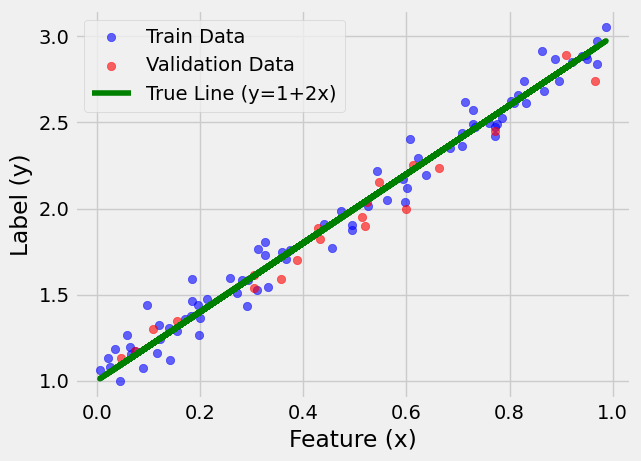

In [7]:
# Vẽ biểu đồ để kiểm tra dữ liệu
plt.scatter(x_train, y_train, label="Train Data", color="blue", alpha=0.6)
plt.scatter(x_val, y_val, label="Validation Data", color="red", alpha=0.6)
plt.plot(x, true_b + true_w * x, label="True Line (y=1+2x)", color="green")
plt.xlabel("Feature (x)")
plt.ylabel("Label (y)")
plt.legend()
plt.show()


##🔥 Tóm tắt 5 bước chính trong Gradient Descent
    Gradient Descent (GD) là thuật toán tối ưu hóa giúp cập nhật các tham số trong mô hình học máy bằng cách giảm thiểu một hàm mất mát (loss function).

    Trong bài toán hồi quy tuyến tính đơn giản y=b+w⋅xy=b+w⋅x, ta cần tìm các giá trị tối ưu của b (bias) và w (weight) sao cho mô hình dự đoán y'​ gần với giá trị thực tế y nhất.

###📌 Bước 0 - Khởi tạo ngẫu nhiên tham số

    Trước khi huấn luyện, ta cần khởi tạo ngẫu nhiên các tham số b và w:

In [8]:
np.random.seed(42)
b = np.random.randn(1)  # Bias (hệ số tự do)
w = np.random.randn(1)  # Hệ số góc
print(b, w)

[0.49671415] [-0.1382643]


📌 Ý nghĩa: Ban đầu, tham số chưa được tối ưu hóa nên giá trị dự đoán sẽ sai.

###📌 Bước 1 - Tính toán dự đoán của mô hình

    Dự đoán được tính bằng phương trình hồi quy tuyến tính:
    y'=b+w⋅x

In [9]:
yhat = b + w * x_train


📌 Ý nghĩa: Đây là bước forward pass, tính toán đầu ra dựa trên tham số hiện tại.

###📌 Bước 2 - Tính toán hàm mất mát (Loss Function)

    Sử dụng Mean Squared Error (MSE):
    * Loss=1/N∑(y−y'​)^2

In [10]:
error = (yhat - y_train)  # Sai số giữa dự đoán và thực tế
loss = (error ** 2).mean()  # Trung bình bình phương sai số
print(loss)


2.7421577700550976


📌 Ý nghĩa: Giá trị loss càng nhỏ, mô hình càng chính xác.

###📌 Bước 3 – Tính toán Gradient (Gradient Computation)

    Gradient cho biết hướng và độ lớn cần thay đổi của tham số để giảm mất mát.

    Tính toán gradient cho b và w:
    * ∂J/∂b=2⋅error.mean()
    * ∂J/∂w=2⋅(x⋅error).mean()

In [11]:
b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()
print(f"Gradient: db = {b_grad}, dw = {w_grad}")


Gradient: db = -3.044811379650508, dw = -1.8337537171510832


📌 Ý nghĩa: Gradient càng lớn, tham số thay đổi càng mạnh.

###📌 Bước 4 – Cập nhật tham số (Gradient Update)

    Công thức cập nhật:
    * b=b−α⋅bgrad
    * w=w−α⋅wgrad

    Với α (learning rate) là tốc độ học.

In [12]:
lr = 0.1  # Learning rate
b = b - lr * b_grad
w = w - lr * w_grad
print(f"Cập nhật: b = {b}, w = {w}")


Cập nhật: b = [0.80119529], w = [0.04511107]


📌 Ý nghĩa: Cập nhật tham số theo hướng giảm mất mát.

###📌 Bước 5 – Lặp lại quá trình (Epochs)

    Một epoch hoàn thành khi tất cả dữ liệu được dùng để cập nhật tham số.
    Cần nhiều epoch để mô hình học tốt hơn.

🔄 Lặp lại toàn bộ quá trình nhiều lần để mô hình tối ưu hóa tham số.

In [13]:
epochs = 100  # Số lần huấn luyện
for epoch in range(epochs):
    yhat = b + w * x_train  # Bước 1: Dự đoán
    error = (yhat - y_train)  # Bước 2: Tính lỗi
    loss = (error ** 2).mean()  # Tính loss
    b_grad = 2 * error.mean()  # Bước 3: Gradient của b
    w_grad = 2 * (x_train * error).mean()  # Gradient của w
    b = b - lr * b_grad  # Bước 4: Cập nhật b
    w = w - lr * w_grad  # Cập nhật w
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss}")


Epoch 0: Loss = 1.634931811122577
Epoch 10: Loss = 0.1575415347965741
Epoch 20: Loss = 0.11481719415171905
Epoch 30: Loss = 0.08678118835665372
Epoch 40: Loss = 0.06611528473896533
Epoch 50: Loss = 0.050873569723487645
Epoch 60: Loss = 0.03963232609732108
Epoch 70: Loss = 0.03134155569806096
Epoch 80: Loss = 0.02522685201378836
Epoch 90: Loss = 0.020717065908771825


📌 Ý nghĩa: Mỗi epoch giúp mô hình học dần dần để tối ưu hóa tham số.

####📌 Các loại Gradient Descent và ảnh hưởng đến Epoch
1️⃣ Batch Gradient Descent (BGD)

    Sử dụng toàn bộ dữ liệu huấn luyện để tính gradient và cập nhật tham số.
    Mỗi epoch chỉ có 1 lần cập nhật.
    Ổn định nhưng có thể chậm với dữ liệu lớn.

📌 Ví dụ: Nếu N = 1000, thì số lần cập nhật mỗi epoch = 1.

In [14]:
for epoch in range(epochs):
    yhat = b + w * x_train  # Dự đoán toàn bộ dữ liệu
    loss = ((yhat - y_train) ** 2).mean()  # Tính loss
    b_grad = 2 * (yhat - y_train).mean()  # Gradient của b
    w_grad = 2 * (x_train * (yhat - y_train)).mean()  # Gradient của w
    b -= lr * b_grad  # Cập nhật b
    w -= lr * w_grad  # Cập nhật w


2️⃣ Stochastic Gradient Descent (SGD)

    Cập nhật sau từng điểm dữ liệu.
    Mỗi epoch có N lần cập nhật.
    Hội tụ nhanh hơn nhưng có thể dao động mạnh.

📌 Ví dụ: Nếu N = 1000, thì số lần cập nhật mỗi epoch = 1000.

In [15]:
for epoch in range(epochs):
    for i in range(N):  # Duyệt từng điểm dữ liệu
        yhat = b + w * x_train[i]  # Dự đoán từng điểm
        error = yhat - y_train[i]  # Tính sai số
        b_grad = 2 * error  # Gradient của b
        w_grad = 2 * x_train[i] * error  # Gradient của w
        b -= lr * b_grad  # Cập nhật b
        w -= lr * w_grad  # Cập nhật w


IndexError: index 80 is out of bounds for axis 0 with size 80

3️⃣ Mini-batch Gradient Descent (MBGD)

    Chia dữ liệu thành nhiều mini-batch (tập con nhỏ, ví dụ: 32, 64 điểm).
    Mỗi epoch có N/nN/n lần cập nhật.
    Cân bằng giữa tốc độ và ổn định.

📌 Ví dụ: Nếu N = 1000, batch size = 50, thì số lần cập nhật mỗi epoch = 1000/50 = 20.

In [ ]:
batch_size = 50
for epoch in range(epochs):
    np.random.shuffle(x_train)  # Xáo trộn dữ liệu
    for i in range(0, N, batch_size):  # Lấy từng batch nhỏ
        x_batch = x_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        yhat = b + w * x_batch  # Dự đoán batch
        error = yhat - y_batch
        b_grad = 2 * error.mean()
        w_grad = 2 * (x_batch * error).mean()
        b -= lr * b_grad
        w -= lr * w_grad

##📌 Giải thích chi tiết về Linear Regression bằng Numpy

Bài toán hồi quy tuyến tính (Linear Regression) nhằm tìm một đường thẳng tối ưu nhất để mô tả mối quan hệ giữa biến đầu vào x và biến đầu ra y, theo công thức:
- y=b+w⋅x

Trong đó:

    bb (bias/intercept) là hệ số chặn (điểm giao với trục tung)
    ww (weight) là trọng số (độ dốc của đường thẳng)
    xx là đầu vào
    yy là giá trị dự đoán

Nhiệm vụ của chúng ta là tìm giá trị tối ưu của bb và ww để sai số giữa giá trị dự đoán y và giá trị thực tế ytrain​ là nhỏ nhất.

###🚀 Các bước thực hiện Linear Regression bằng Gradient Descent

Ta sử dụng Gradient Descent để tối ưu hóa mô hình, bao gồm 5 bước chính:

🔹 Bước 0: Khởi tạo tham số ngẫu nhiên

    Đặt seed để đảm bảo tính tái lập kết quả.
    Khởi tạo bb và ww với các giá trị ngẫu nhiên.

In [16]:
import numpy as np

# Step 0 - Initializes parameters "b" and "w" randomly
np.random.seed(42)
b = np.random.randn(1)  # Hệ số chặn
w = np.random.randn(1)  # Trọng số
print(b, w)


[0.49671415] [-0.1382643]


🔹 Bước 1: Dự đoán đầu ra (Forward Pass)

Sử dụng công thức y=b+w⋅xđể tính giá trị dự đoán.

In [17]:
# Step 1 - Computes model's predicted output - forward pass
yhat = b + w * x_train


🔹 Bước 2: Tính toán hàm mất mát (Loss Function)

    Sử dụng Mean Squared Error (MSE) để đo sai số:
    Loss=1/N∑(yhat−ytrain)^2
    

In [18]:
# Step 2 - Computes the loss
error = yhat - y_train  # Sai số giữa dự đoán và thực tế
loss = (error ** 2).mean()  # Tính trung bình bình phương sai số
print(loss)


2.7421577700550976


🔹 Bước 3: Tính toán Gradient

    Gradient là đạo hàm của Loss theo bb và ww, cho biết cần điều chỉnh tham số theo hướng nào để giảm lỗi.

    ∂Loss/∂b=2⋅mean(yhat−ytrain)
    ∂Loss/∂w=2⋅mean(xtrain⋅(yhat−ytrain))


In [19]:
# Step 3 - Computes gradients for both "b" and "w"
b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()
print(b_grad, w_grad)


-3.044811379650508 -1.8337537171510832


🔹 Bước 4: Cập nhật tham số

    Gradient Descent cập nhật tham số theo công thức:
    b=b−η⋅∂Loss/∂b
    w=w−η⋅∂Loss/∂w

In [20]:
# Step 4 - Updates parameters using gradients and learning rate
lr = 0.1  # Learning rate
b = b - lr * b_grad
w = w - lr * w_grad
print(b, w)


[0.80119529] [0.04511107]


🔹 Bước 5: Lặp lại quá trình (Epochs)

    Chạy nhiều epoch để mô hình hội tụ.

In [21]:
# Định nghĩa số epoch
n_epochs = 1000

for epoch in range(n_epochs):
    # Forward pass
    yhat = b + w * x_train

    # Compute loss
    error = yhat - y_train
    loss = (error ** 2).mean()

    # Compute gradients
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()

    # Update parameters
    b = b - lr * b_grad
    w = w - lr * w_grad

print(b, w)  # In giá trị cuối cùng của b, w


[1.02354093] [1.96896412]


##Pytorch

###Giải thích nội dung về PyTorch và Tensor
1. Tensors trong PyTorch là gì?

Trong Deep Learning, dữ liệu đầu vào, trọng số và kết quả dự đoán đều được biểu diễn dưới dạng tensor.

    Scalar: Một số đơn lẻ, có 0 chiều (ví dụ: torch.tensor(3.14159))
    Vector: Một mảng có 1 chiều (ví dụ: torch.tensor([1, 2, 3]))
    Matrix: Một mảng 2 chiều (ví dụ: torch.ones((2, 3)))
    Tensor: Mảng có 3 chiều trở lên (ví dụ: torch.randn((2, 3, 4)))

📌 Lưu ý: Trong PyTorch, tensor có thể có bất kỳ số chiều nào, nhưng thường ta chỉ làm việc với vector (1D), ma trận (2D) và tensor (3D trở lên).

2. Tạo và thao tác với Tensor trong PyTorch

Tương tự như NumPy, PyTorch cung cấp nhiều phương thức để tạo tensor:

In [22]:

scalar = torch.tensor(3.14159)  # Scalar (0 chiều)
vector = torch.tensor([1, 2, 3])  # Vector (1 chiều)
matrix = torch.ones((2, 3))  # Ma trận (2 chiều) gồm toàn số 1
tensor = torch.randn((2, 3, 4))  # Tensor (3 chiều) với giá trị ngẫu nhiên


In [23]:
print(tensor.size(), tensor.shape)
# Output: torch.Size([2, 3, 4]) torch.Size([2, 3, 4])


torch.Size([2, 3, 4]) torch.Size([2, 3, 4])


3. Thay đổi hình dạng của Tensor

Chúng ta có thể thay đổi kích thước của tensor bằng .view() hoặc .reshape():

In [24]:
same_matrix = matrix.view(1, 6)  # Chuyển từ (2,3) thành (1,6)


📌 Lưu ý quan trọng:

    .view() không tạo tensor mới mà chỉ thay đổi cách nhìn dữ liệu, do đó nếu thay đổi phần tử trong same_matrix, giá trị của matrix cũng bị thay đổi.
    .reshape() có thể tạo bản sao hoặc không, tuỳ trường hợp.

4. Tạo bản sao dữ liệu trong Tensor

Nếu muốn tạo một bản sao thực sự của tensor (không ảnh hưởng đến tensor gốc), ta có thể dùng .clone().detach():

In [25]:
new_matrix = matrix.clone().detach()


📌 Giải thích:

    .clone(): Tạo một bản sao dữ liệu mới.
    .detach(): Tách tensor khỏi computation graph, giúp nó không bị ảnh hưởng bởi quá trình lan truyền gradient (backpropagation) trong quá trình huấn luyện mô hình.

##Loading Data, Devices, and CUDA

1. Chuyển đổi từ NumPy sang PyTorch Tensor

    Khi làm việc với dữ liệu trong NumPy (x_train, y_train), chúng ta cần chuyển đổi chúng sang PyTorch Tensor để sử dụng trong huấn luyện mô hình. Có hai cách chính để làm điều này:
Cách 1: Dùng torch.as_tensor()

In [26]:
x_train_tensor = torch.as_tensor(x_train)
x_train.dtype, x_train_tensor.dtype

(dtype('float64'), torch.float64)

Cách 2: Dùng torch.tensor()

In [27]:
x_train_tensor = torch.tensor(x_train)


2. Chuyển đổi kiểu dữ liệu Tensor

Khi chuyển đổi từ NumPy sang PyTorch, dữ liệu sẽ giữ nguyên kiểu dữ liệu (dtype). Ví dụ:

In [28]:
float_tensor = x_train_tensor.float()
print(float_tensor.dtype)  # Output: torch.float32


torch.float32


3. Chạy trên CPU và GPU
+ Kiểm tra GPU

    PyTorch hỗ trợ GPU (NVIDIA) thông qua CUDA. Để kiểm tra xem GPU có sẵn không, dùng:

In [29]:
print(torch.cuda.is_available())

True


In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)  # 'cuda' nếu có GPU, 'cpu' nếu không có


cuda


In [31]:
!apt install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [32]:
!git config --global user.email "huynhcongan2442004@gmail.com"
!git config --global user.name "anhuynh2404"

In [33]:
!git clone https://github.com/Anhuynh2404/Deeplearning_Stepbystep-Study.git

Cloning into 'Deeplearning_Stepbystep-Study'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 21 (delta 7), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 8.86 KiB | 8.86 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [36]:
!ls -a

.   .config    data_preparation		      model_configuration  plots	runs
..  config.py  Deeplearning_Stepbystep-Study  model_training	   __pycache__	sample_data
